In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
from pathlib import Path
from collections import Counter

In [2]:
# Config
PC9_XYZ_DIR = Path("/home/colmanok/Code/QM9/data/PC9_data/XYZ")
MODEL_PATH  = Path("/home/colmanok/Code/QM9/data/PC9_data/MODEL.xyz")

xyz_files = sorted(PC9_XYZ_DIR.glob("*.xyz"))
print(f"Total moléculas: {len(xyz_files):,}")

Total moléculas: 99,234


In [3]:
# Leer columnas desde MODEL.xyz
with open(MODEL_PATH, "r") as f:
    lines = f.readlines()

prop_keys = lines[1].strip().split("\t")
print("Propiedades disponibles:")
for i, k in enumerate(prop_keys):
    print(f"  [{i}] {k}")

Propiedades disponibles:
  [0] tag id
  [1] HOMO-1
  [2] LUMO+1
  [3] 0.0
  [4] 0.0
  [5] 0.0
  [6] HOMO
  [7] LUMO
  [8] gap
  [9] 0.0
  [10] 0.0
  [11] E
  [12] 0.0
  [13] 0.0
  [14] 0.0
  [15] 0.0


In [12]:
# Parser PC9 .xyz
ATOMIC_NUMBERS = {
    "H": 1, "C": 6, "N": 7, "O": 8, "F": 9,
    "S": 16, "Cl": 17, "P": 15
}

def parse_pc9_xyz(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()

    n_atoms = int(lines[0].strip())

    # línea 1: propiedades separadas por tab
    prop_values = lines[1].strip().split("\t")

    mol_id = prop_values[1]
    energy = float(prop_values[11])   # columna E
    homo   = float(prop_values[6])    # columna HOMO
    lumo   = float(prop_values[7])    # columna LUMO
    gap    = float(prop_values[8])    # columna gap

    Z       = []
    R       = []
    charges = []
    symbols = []

    for i in range(n_atoms):
        parts  = lines[2 + i].split()
        symbol = parts[0]
        x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
        q = float(parts[4])

        Z.append(ATOMIC_NUMBERS.get(symbol, 0))
        R.append([x, y, z])
        charges.append(q)
        symbols.append(symbol)

    return {
        "mol_id":  mol_id,
        "n_atoms": n_atoms,
        "symbols": symbols,
        "Z":       np.array(Z,       dtype=np.int32),
        "R":       np.array(R,       dtype=np.float32),
        "charges": np.array(charges, dtype=np.float32),
        "energy":  energy,
        "homo":    homo,
        "lumo":    lumo,
        "gap":     gap,
    }

In [13]:
# Verificar parser con un ejemplo antes de parsear todo
example = parse_pc9_xyz(xyz_files[0])
print(f"mol_id:  {example['mol_id']}")
print(f"n_atoms: {example['n_atoms']}")
print(f"symbols: {example['symbols']}")
print(f"energy:  {example['energy']} Hartree")
print(f"homo:    {example['homo']}")
print(f"lumo:    {example['lumo']}")
print(f"gap:     {example['gap']}")
print(f"R[0]:    {example['R'][0]}")
print(f"q[0]:    {example['charges'][0]}")

mol_id:  -0.2699000000
n_atoms: 14
symbols: ['C', 'C', 'C', 'N', 'O', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
energy:  -249.6945983259 Hartree
homo:    -0.2274
lumo:    0.0679
gap:     0.2953
R[0]:    [ 0.8709267  -0.05925883 -0.09321001]
q[0]:    -0.4646010100841522


In [14]:
# Parseo completo — puede tardar unos minutos con ~99k moléculas
records = []

for i, xyz_file in enumerate(xyz_files):
    try:
        mol = parse_pc9_xyz(xyz_file)
        element_counts = Counter(mol["symbols"])
        records.append({
            "mol_id":  mol["mol_id"],
            "n_atoms": mol["n_atoms"],
            "energy":  mol["energy"],
            "homo":    mol["homo"],
            "lumo":    mol["lumo"],
            "gap":     mol["gap"],
            "n_H":  element_counts.get("H",  0),
            "n_C":  element_counts.get("C",  0),
            "n_N":  element_counts.get("N",  0),
            "n_O":  element_counts.get("O",  0),
            "n_F":  element_counts.get("F",  0),
            "n_S":  element_counts.get("S",  0),
            "n_Cl": element_counts.get("Cl", 0),
        })
    except Exception as e:
        print(f"[WARN] {xyz_file.name}: {e}")

    if i % 10000 == 0:
        print(f"Parseadas: {i:,} / {len(xyz_files):,}")

df = pd.DataFrame(records)
print(f"\nTotal parseadas: {len(df):,}")
display(df.describe().T.round(4))

Parseadas: 0 / 99,234
Parseadas: 10,000 / 99,234
Parseadas: 20,000 / 99,234
Parseadas: 30,000 / 99,234
Parseadas: 40,000 / 99,234
Parseadas: 50,000 / 99,234
Parseadas: 60,000 / 99,234
Parseadas: 70,000 / 99,234
Parseadas: 80,000 / 99,234
Parseadas: 90,000 / 99,234

Total parseadas: 99,234


,count,mean,std,min,25%,50%,75%,max
n_atoms,99234.0,18.0783,4.1634,2.0000,15.0000,18.0000,21.0000,29.0000
energy,99234.0,-390.9304,64.8486,-750.4884,-426.1360,-389.6869,-351.3448,-40.5184
homo,99234.0,-0.2333,0.0296,-0.4285,-0.2514,-0.2335,-0.2145,-0.0862
lumo,99234.0,0.0097,0.0506,-0.2519,-0.0260,0.0124,0.0513,0.1790
gap,99234.0,0.2430,0.0517,0.0152,0.2061,0.2440,0.2782,0.6075
n_H,99234.0,9.8808,3.6435,0.0000,7.0000,10.0000,12.0000,20.0000
n_C,99234.0,5.6754,1.5838,0.0000,5.0000,6.0000,7.0000,9.0000
n_N,99234.0,1.2048,1.1490,0.0000,0.0000,1.0000,2.0000,9.0000
n_O,99234.0,1.1667,1.0528,0.0000,0.0000,1.0000,2.0000,7.0000
n_F,99234.0,0.1506,0.5739,0.0000,0.0000,0.0000,0.0000,6.0000


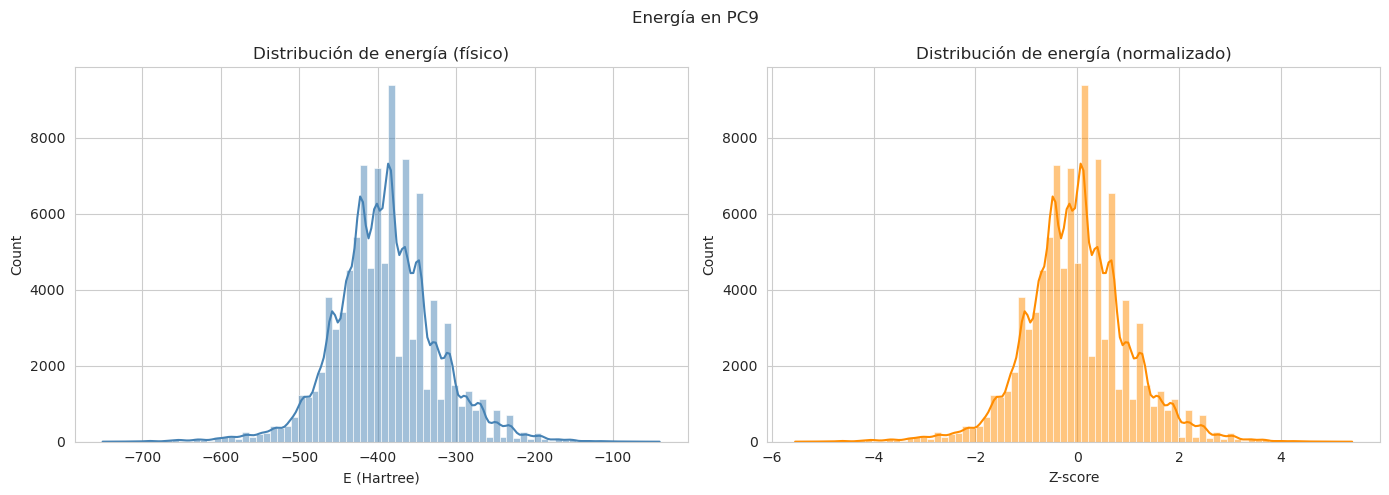

Min:  -750.4884 Ha
Max:  -40.5184 Ha
Mean: -390.9304 Ha
Std:  64.8486 Ha


In [15]:
# Distribución de energía — físico y normalizado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["energy"], bins=80, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de energía (físico)")
axes[0].set_xlabel("E (Hartree)")
axes[0].set_ylabel("Count")

e_norm = (df["energy"] - df["energy"].mean()) / df["energy"].std()
sns.histplot(e_norm, bins=80, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribución de energía (normalizado)")
axes[1].set_xlabel("Z-score")
axes[1].set_ylabel("Count")

plt.suptitle("Energía en PC9")
plt.tight_layout()
plt.show()

print(f"Min:  {df['energy'].min():.4f} Ha")
print(f"Max:  {df['energy'].max():.4f} Ha")
print(f"Mean: {df['energy'].mean():.4f} Ha")
print(f"Std:  {df['energy'].std():.4f} Ha")

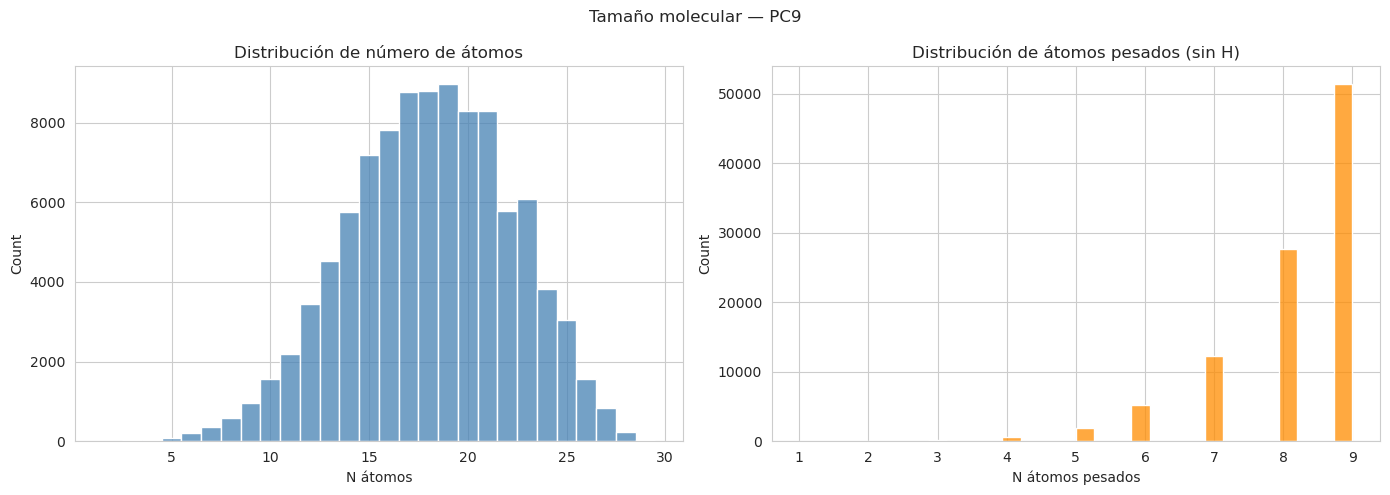

Min átomos:  2
Max átomos:  29
Mean átomos: 18.08
Std átomos:  4.16


In [16]:
# Distribución de tamaño molecular
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(df["n_atoms"].min(), df["n_atoms"].max() + 2) - 0.5
sns.histplot(df["n_atoms"], bins=bins, kde=False, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de número de átomos")
axes[0].set_xlabel("N átomos")
axes[0].set_ylabel("Count")

n_heavy = df["n_atoms"] - df["n_H"]
sns.histplot(n_heavy, bins=30, kde=False, ax=axes[1], color="darkorange")
axes[1].set_title("Distribución de átomos pesados (sin H)")
axes[1].set_xlabel("N átomos pesados")
axes[1].set_ylabel("Count")

plt.suptitle("Tamaño molecular — PC9")
plt.tight_layout()
plt.show()

print(f"Min átomos:  {df['n_atoms'].min()}")
print(f"Max átomos:  {df['n_atoms'].max()}")
print(f"Mean átomos: {df['n_atoms'].mean():.2f}")
print(f"Std átomos:  {df['n_atoms'].std():.2f}")

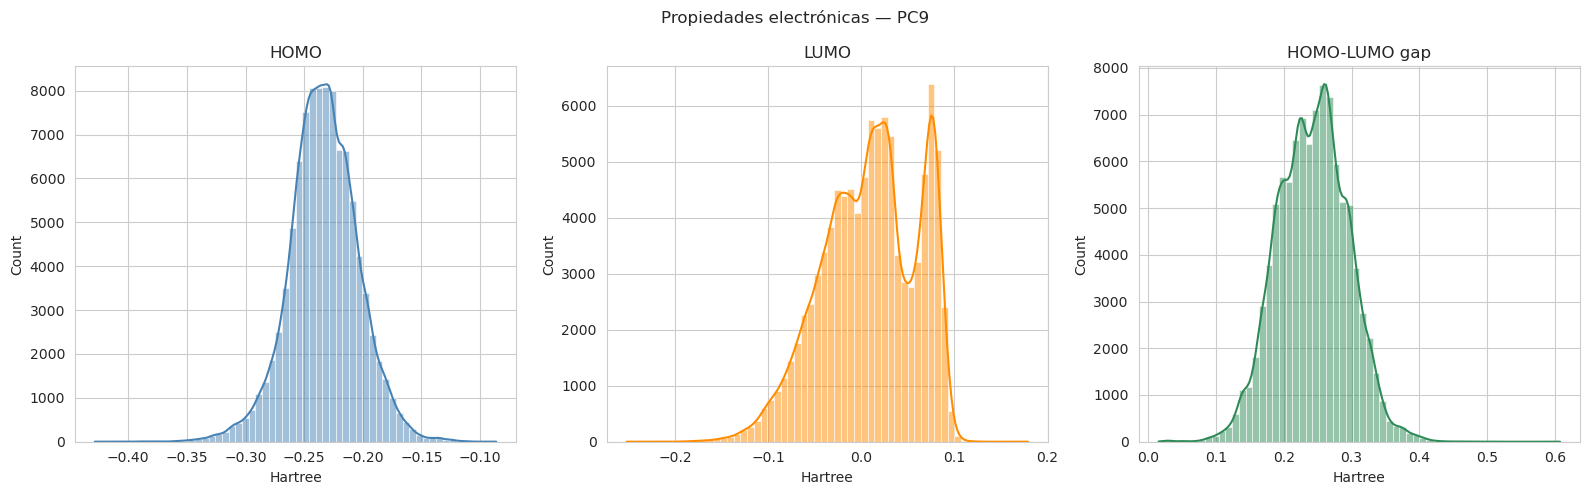

In [9]:
# Propiedades electrónicas: HOMO, LUMO, gap
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(df["homo"], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("HOMO")
axes[0].set_xlabel("Hartree")
axes[0].set_ylabel("Count")

sns.histplot(df["lumo"], bins=60, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("LUMO")
axes[1].set_xlabel("Hartree")
axes[1].set_ylabel("Count")

sns.histplot(df["gap"], bins=60, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("HOMO-LUMO gap")
axes[2].set_xlabel("Hartree")
axes[2].set_ylabel("Count")

plt.suptitle("Propiedades electrónicas — PC9")
plt.tight_layout()
plt.show()

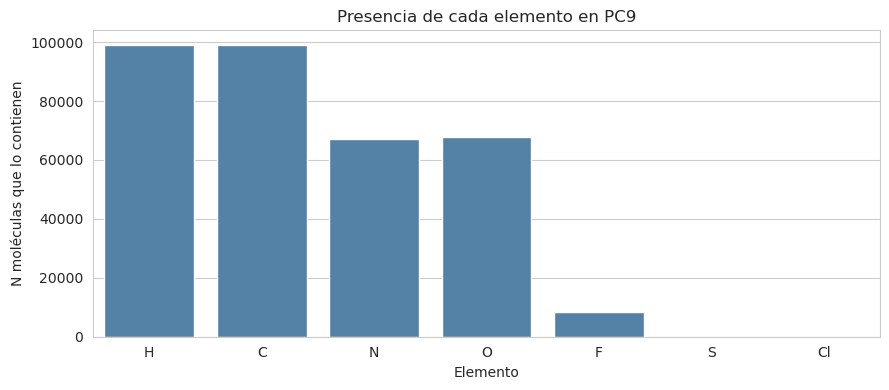

,elemento,n_moleculas
0,H,98948
1,C,99041
2,N,67106
3,O,67814
4,F,8408
5,S,0
6,Cl,0


In [17]:
# Composición elemental — presencia de cada elemento
element_cols = ["n_H", "n_C", "n_N", "n_O", "n_F", "n_S", "n_Cl"]
presence = {c.replace("n_", ""): (df[c] > 0).sum() for c in element_cols}
df_presence = pd.DataFrame(list(presence.items()), columns=["elemento", "n_moleculas"])

plt.figure(figsize=(9, 4))
sns.barplot(data=df_presence, x="elemento", y="n_moleculas", color="steelblue")
plt.title("Presencia de cada elemento en PC9")
plt.xlabel("Elemento")
plt.ylabel("N moléculas que lo contienen")
plt.tight_layout()
plt.show()

display(df_presence)

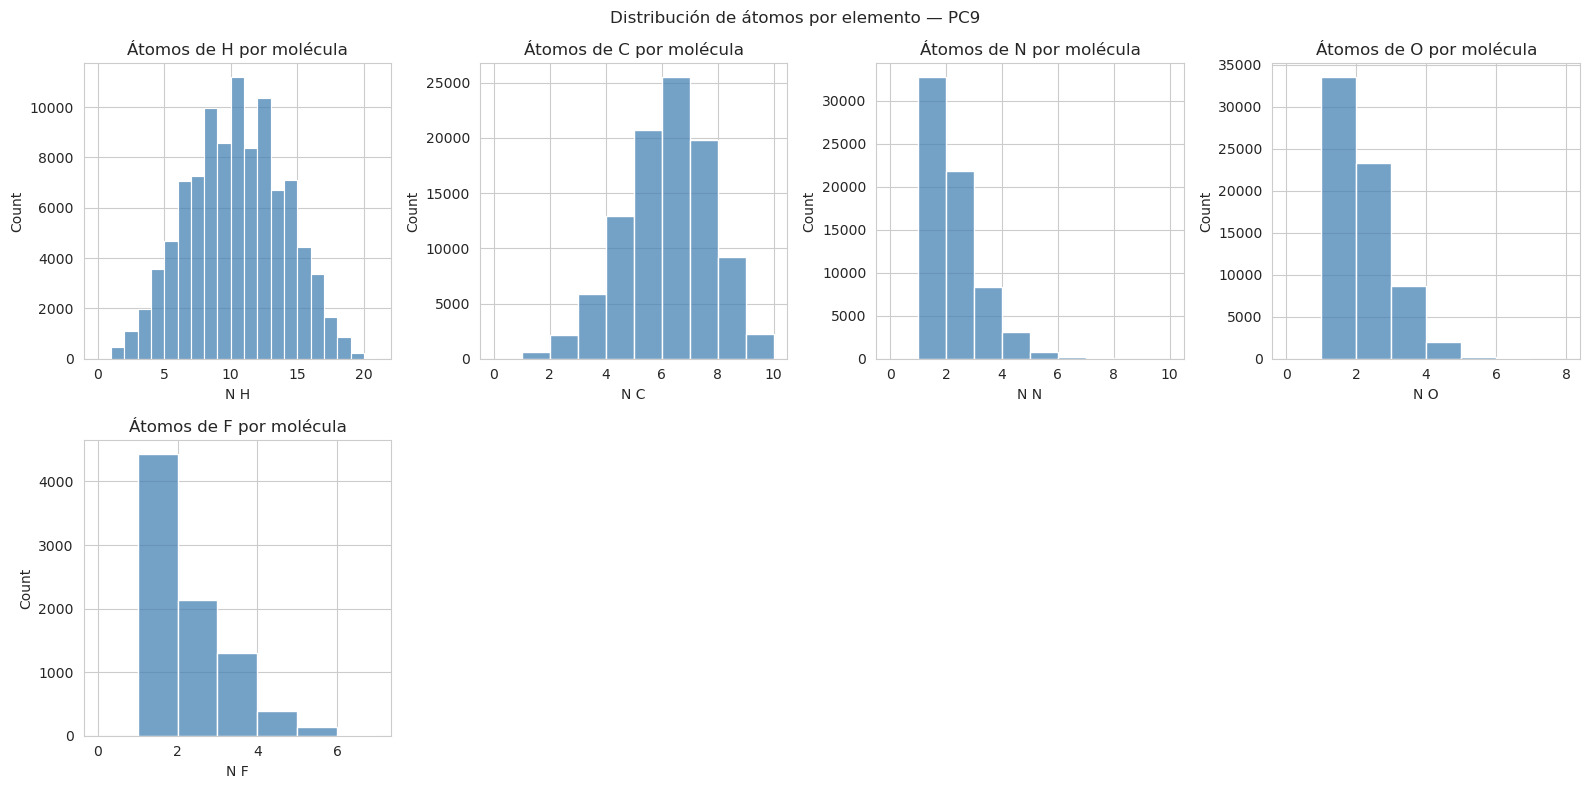

In [18]:
# Distribución de átomos por elemento
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(element_cols):
    data = df[df[col] > 0][col]
    if data.empty:
        axes[idx].set_visible(False)
        continue
    sns.histplot(data, bins=range(int(data.max()) + 2), kde=False,
                 ax=axes[idx], color="steelblue")
    axes[idx].set_title(f"Átomos de {col.replace('n_', '')} por molécula")
    axes[idx].set_xlabel(f"N {col.replace('n_', '')}")
    axes[idx].set_ylabel("Count")

for idx in range(len(element_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Distribución de átomos por elemento — PC9")
plt.tight_layout()
plt.show()

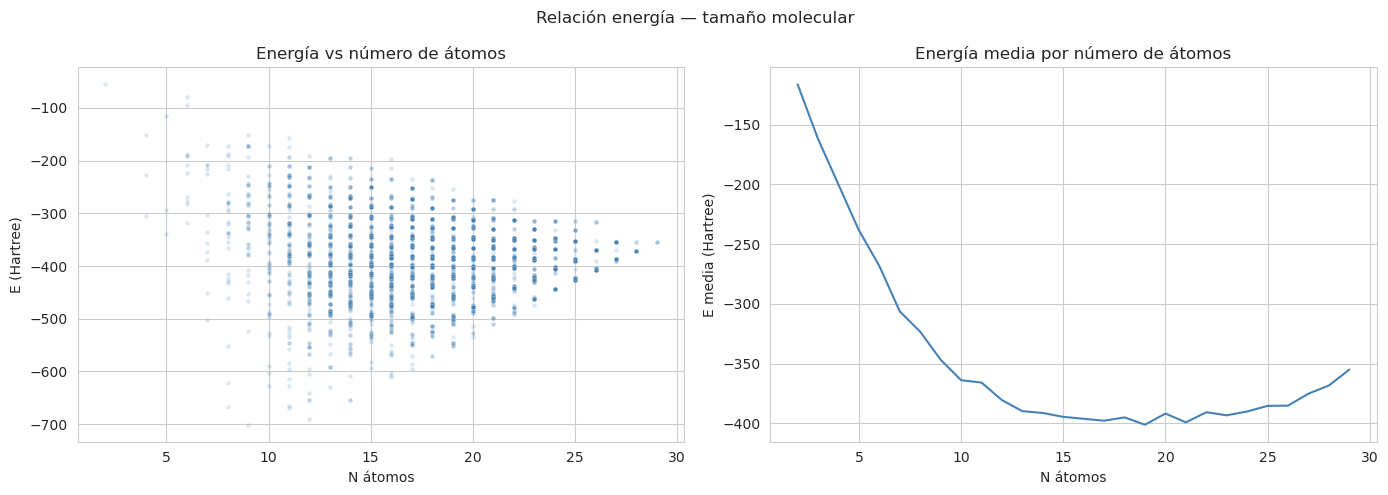

In [19]:
# Energía vs tamaño molecular
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(min(5000, len(df)), random_state=42)

sns.scatterplot(data=sample, x="n_atoms", y="energy",
                alpha=0.2, s=10, ax=axes[0], color="steelblue")
axes[0].set_title("Energía vs número de átomos")
axes[0].set_xlabel("N átomos")
axes[0].set_ylabel("E (Hartree)")

mean_e = df.groupby("n_atoms")["energy"].mean().reset_index()
sns.lineplot(data=mean_e, x="n_atoms", y="energy",
             ax=axes[1], color="steelblue")
axes[1].set_title("Energía media por número de átomos")
axes[1].set_xlabel("N átomos")
axes[1].set_ylabel("E media (Hartree)")

plt.suptitle("Relación energía — tamaño molecular")
plt.tight_layout()
plt.show()

Total PC9:                    99,234
PC9 dentro del rango de QM9:  99,234  (100.0%)
PC9 fuera del rango de QM9:   0 (0.0%)


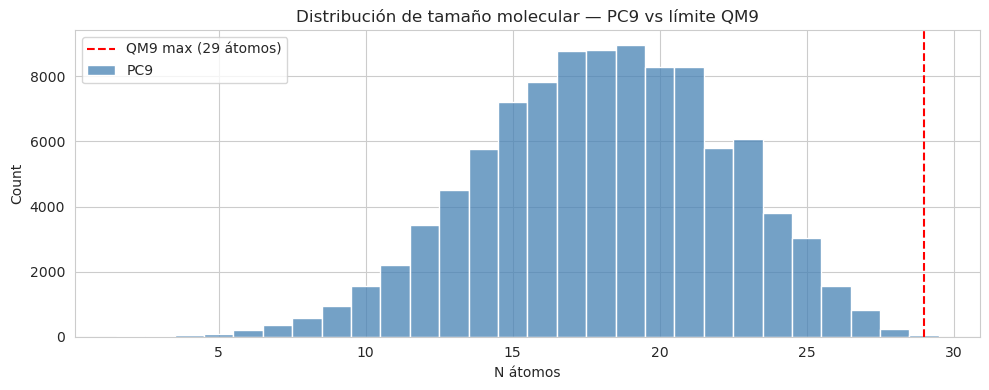

In [20]:
# Comparación rango n_atoms con QM9
QM9_MAX = 29
pc9_in_range  = (df["n_atoms"] <= QM9_MAX).sum()
pc9_out_range = (df["n_atoms"] >  QM9_MAX).sum()

print(f"Total PC9:                    {len(df):,}")
print(f"PC9 dentro del rango de QM9:  {pc9_in_range:,}  ({100*pc9_in_range/len(df):.1f}%)")
print(f"PC9 fuera del rango de QM9:   {pc9_out_range:,} ({100*pc9_out_range/len(df):.1f}%)")

bins = np.arange(df["n_atoms"].min(), df["n_atoms"].max() + 2) - 0.5
plt.figure(figsize=(10, 4))
sns.histplot(df["n_atoms"], bins=bins, kde=False, color="steelblue", label="PC9")
plt.axvline(x=QM9_MAX, color="red", linestyle="--", linewidth=1.5,
            label=f"QM9 max ({QM9_MAX} átomos)")
plt.title("Distribución de tamaño molecular — PC9 vs límite QM9")
plt.xlabel("N átomos")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

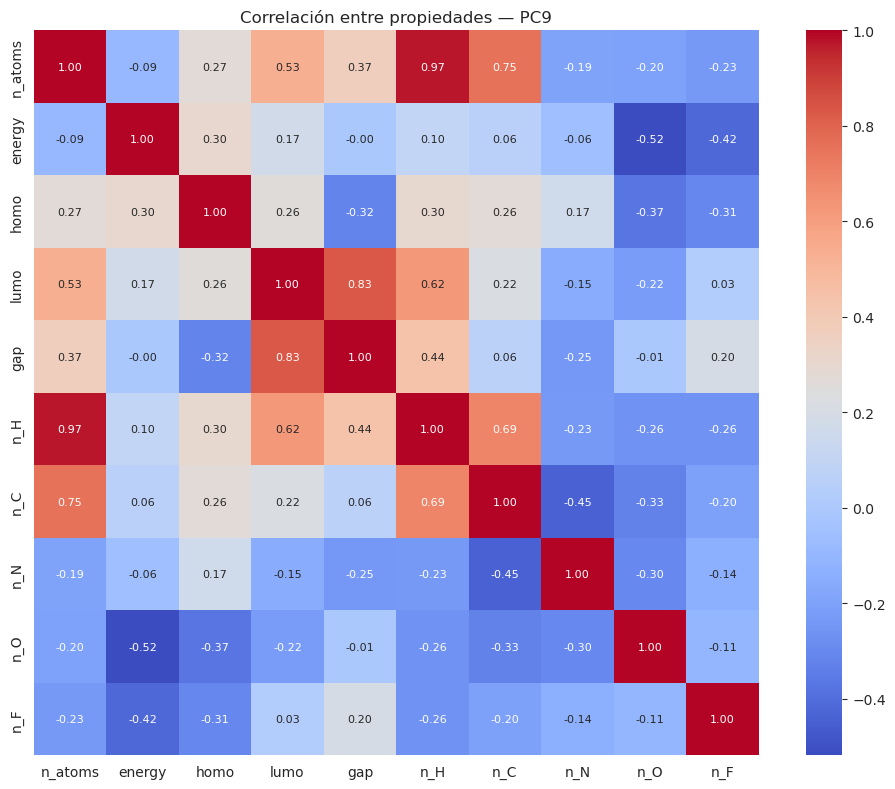

In [21]:
# Correlaciones entre propiedades numéricas
num_cols = ["n_atoms", "energy", "homo", "lumo", "gap",
            "n_H", "n_C", "n_N", "n_O", "n_F"]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            square=True, annot_kws={"size": 8})
plt.title("Correlación entre propiedades — PC9")
plt.tight_layout()
plt.show()